In [146]:
%load_ext autoreload
%autoreload 2


train_url2index = "hdfs://haruna/home/byte_data_seed/lf_lq/speech/data/js/data/music/converted/converted_all_BillboardLyricsDataModule_SpeechTransform/train/0/url2index.txt"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [141]:
from recipes.datasets.billboard import BillboardLyricsDataModule
from samantha.transforms.audio import plot_spectrogram

batch_size = 8

datamodule = BillboardLyricsDataModule(
    sample_rate=24000,
    batch_size=batch_size,
    min_words=5,
    max_words=400,
    shuffle_buffer_size=50,
    min_seconds=2,
    max_seconds=30,
    num_workers=0,
    bucket_interval=5.0
)
train_loader = datamodule.train_dataloader()

batch = next(iter(train_loader))

In [144]:
for idx in range(batch_size):   
    input_length = batch.input_length[idx]
    # ipd.display(ipd.Audio(batch.audio[idx, :, :input_length], rate=24000))
    print(batch.lyrics_text[idx])

And i wish you nothing less than everything youve ever dreamed of <n> And i hope that you find love along the way <n>
I knew this shit wasnt right <n> Appeals gontake time in the field aint no cryintake pills to keep from cryintake money not here to give me advice <n> I seen the hurt in his eyes heard the pain in his voice <n> Yeah when i wanna hear your voice i call your voicemail <n> I put Chicago on my shoulders my shit short still <n>
Well i left a map on your front seat just in case you lose your way <n> But dont worry once you reach Sally saw its all interstate <n>
Say something <n> Im giving up on you and i will swallow my pride <n>
And i wish you nothing less than everything youve ever dreamed of <n> And i hope that you find love along the way <n>
And i am feeling so small <n> It was over my head <n> I know nothing at all <n>
But most of all i wish youd stay <n>
They like to get you there and smile in your face <n> They think youre so cute when they got you in that condition <n

In [196]:
from recipes.datasets.mel_spectrogram.mel_spectrogram import MelDataModule
from samantha.transforms.audio import plot_spectrogram
from recipes.datasets.billboard.billboard import BillboardLyricsFilters

filters = BillboardLyricsFilters(min_words=30, max_words=400)

datamodule = MelDataModule(
    url2index=train_url2index,
    sample_rate=24000,
    hop_size=240,
    batch_size=1,
    shuffle_buffer_size=50,
    resampled=False,
    shardshuffle=False,
    min_seconds=5,
    max_seconds=30,
    num_workers=0,
    pin_memory=True,
    filters=filters,
)

In [197]:
train_loader = datamodule.train_dataloader()

In [198]:
batch = next(iter(train_loader))

22
We could sail the world together <n> Yeah i stopped on them pills stole your heart like a hold up and you aint getting it back <n> Sexing you in like 50 states my chain all on your back <n> Girl you been looking for real love and i got what they lack you a butterfly a good girl <n> Dont follow none of these traps <n> You deserve better baby better baby <n> Yeah fuck <n>


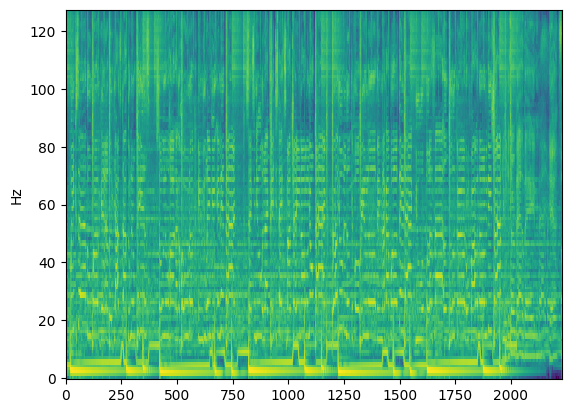

24
Yeah but not tonight <n> Not tonight <n> Yeah <n> I just wanna fuck you right <n> Fuck you right <n> Take you down <n> Take you down to the ground <n> Ground <n> Make the oh i sound oh oh not tonight <n> Not tonight <n> Yeah yeah yeah <n>


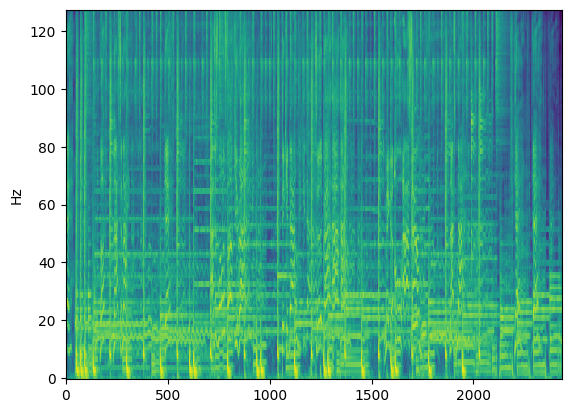

19
Fucking with this clown <n> Pack your bags and we can leave now girl <n> Dont let them bring you down <n> You deserve better baby <n> Let a real nigga bring you wealth <n> These lames bad for your health <n> You can do bad all by yourself <n> You deserve better baby <n> All i wanna do do <n>


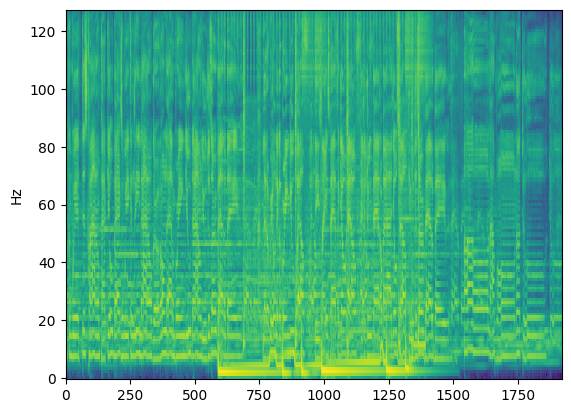

23
I have it all of her beauty <n> Just a martyr of the blood <n> How can you just circle <n> Im holding on to a life ill never get back <n> I still want to let go <n> Im on the right train but the wrong tracks <n> Trying not to erase nothing is <n>


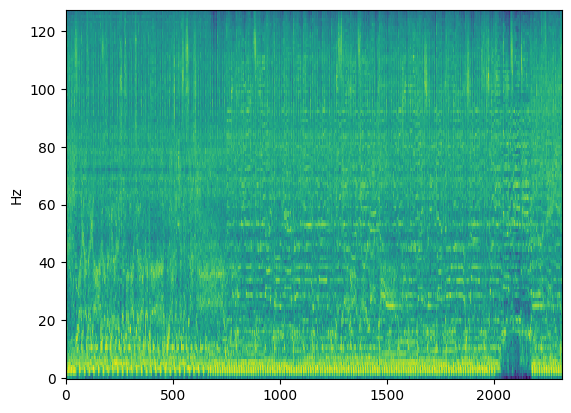

24
We saw you standing at the scene <n> Its a crime <n> You tried to play it off said you werent there at the time <n> Whatever happens to come from your lips im only saying that i wont trip <n> You always gonna try to tell a lie <n>


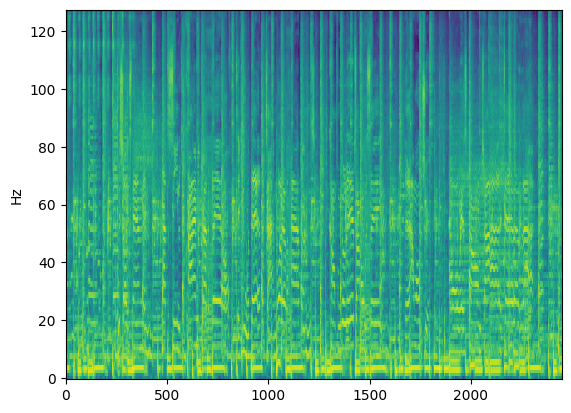

In [202]:
import matplotlib.pyplot as plt
import IPython.display as ipd

for batch_idx, batch in enumerate(train_loader):
    if batch_idx == 5:
        break
    
    # ipd.display(ipd.Audio(batch.audio[0].numpy(), rate=24000))
    print(batch.audio_input_length[0] // datamodule._sample_rate)
    print(batch.index[0]["lyrics_text"])
    plot_spectrogram(batch.mel[0].T, plot_log=False)
    plt.show()